# Mini-Projet : Planification Robuste sur Grille
## A* + Chaînes de Markov
Houda RIYAD | SDIA | ENSET Mohammedia | 2025/2026  
Encadrant : Pr. Mohamed MESTARI

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
sys.path.append('.')

from IPython.display import Image, display
from astar import search, manhattan, euclidean
from markov import build_transition_matrix, verify_stochastic, compute_absorption, identify_classes, goal_probability_over_time
from simulation import monte_carlo, simulate_trajectory
from experiments import experiment_E1, experiment_E2, experiment_E3, experiment_E4, experiment_E5
from grids import GRIDS

print("Imports : DONE!")

Imports : DONE!


## E1 — Comparaison des algorithmes
UCS, Greedy et A* sur 3 grilles.                         
Mesure du nombre de nœuds développés et du coût retourné.


EXPÉRIENCE E1 : Comparaison UCS / Greedy / A*

  Grille FACILE:
  Algo                       Coût    Nœuds  Taille OPEN  Temps(ms)   Trouvé
  ---------------------- -------- -------- ------------ ---------- --------
  UCS                        14.0       54            7      0.317      Oui
  Greedy                     14.0       15            9      0.093      Oui
  A*                         14.0       54            7      0.276      Oui
  A*                         14.0       54            7      0.295      Oui
  Weighted A* (w=2.0)        14.0       15            9      0.086      Oui

  Grille MOYENNE:
  Algo                       Coût    Nœuds  Taille OPEN  Temps(ms)   Trouvé
  ---------------------- -------- -------- ------------ ---------- --------
  UCS                        22.0      102           10      0.439      Oui
  Greedy                     22.0       23            8      0.101      Oui
  A*                         22.0      102           10      0.390      Oui
  A*

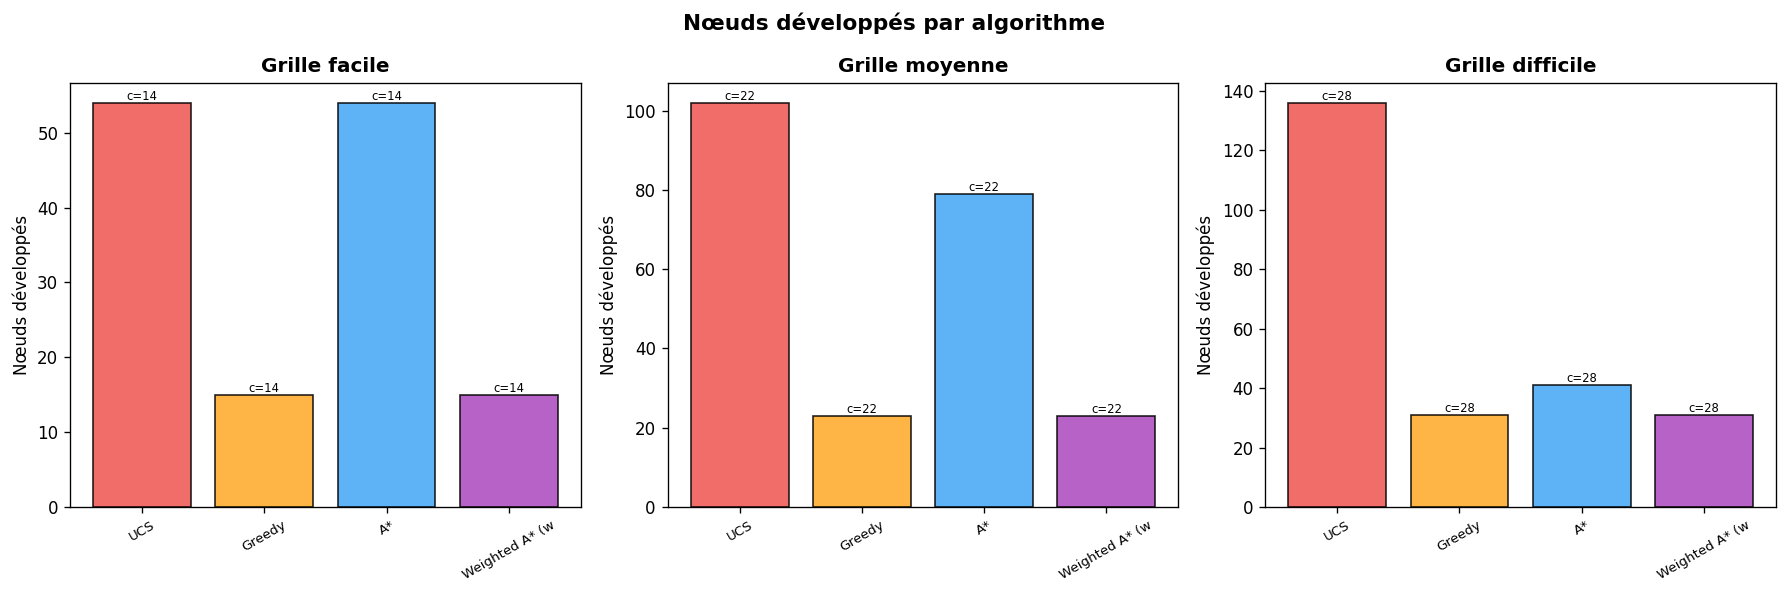

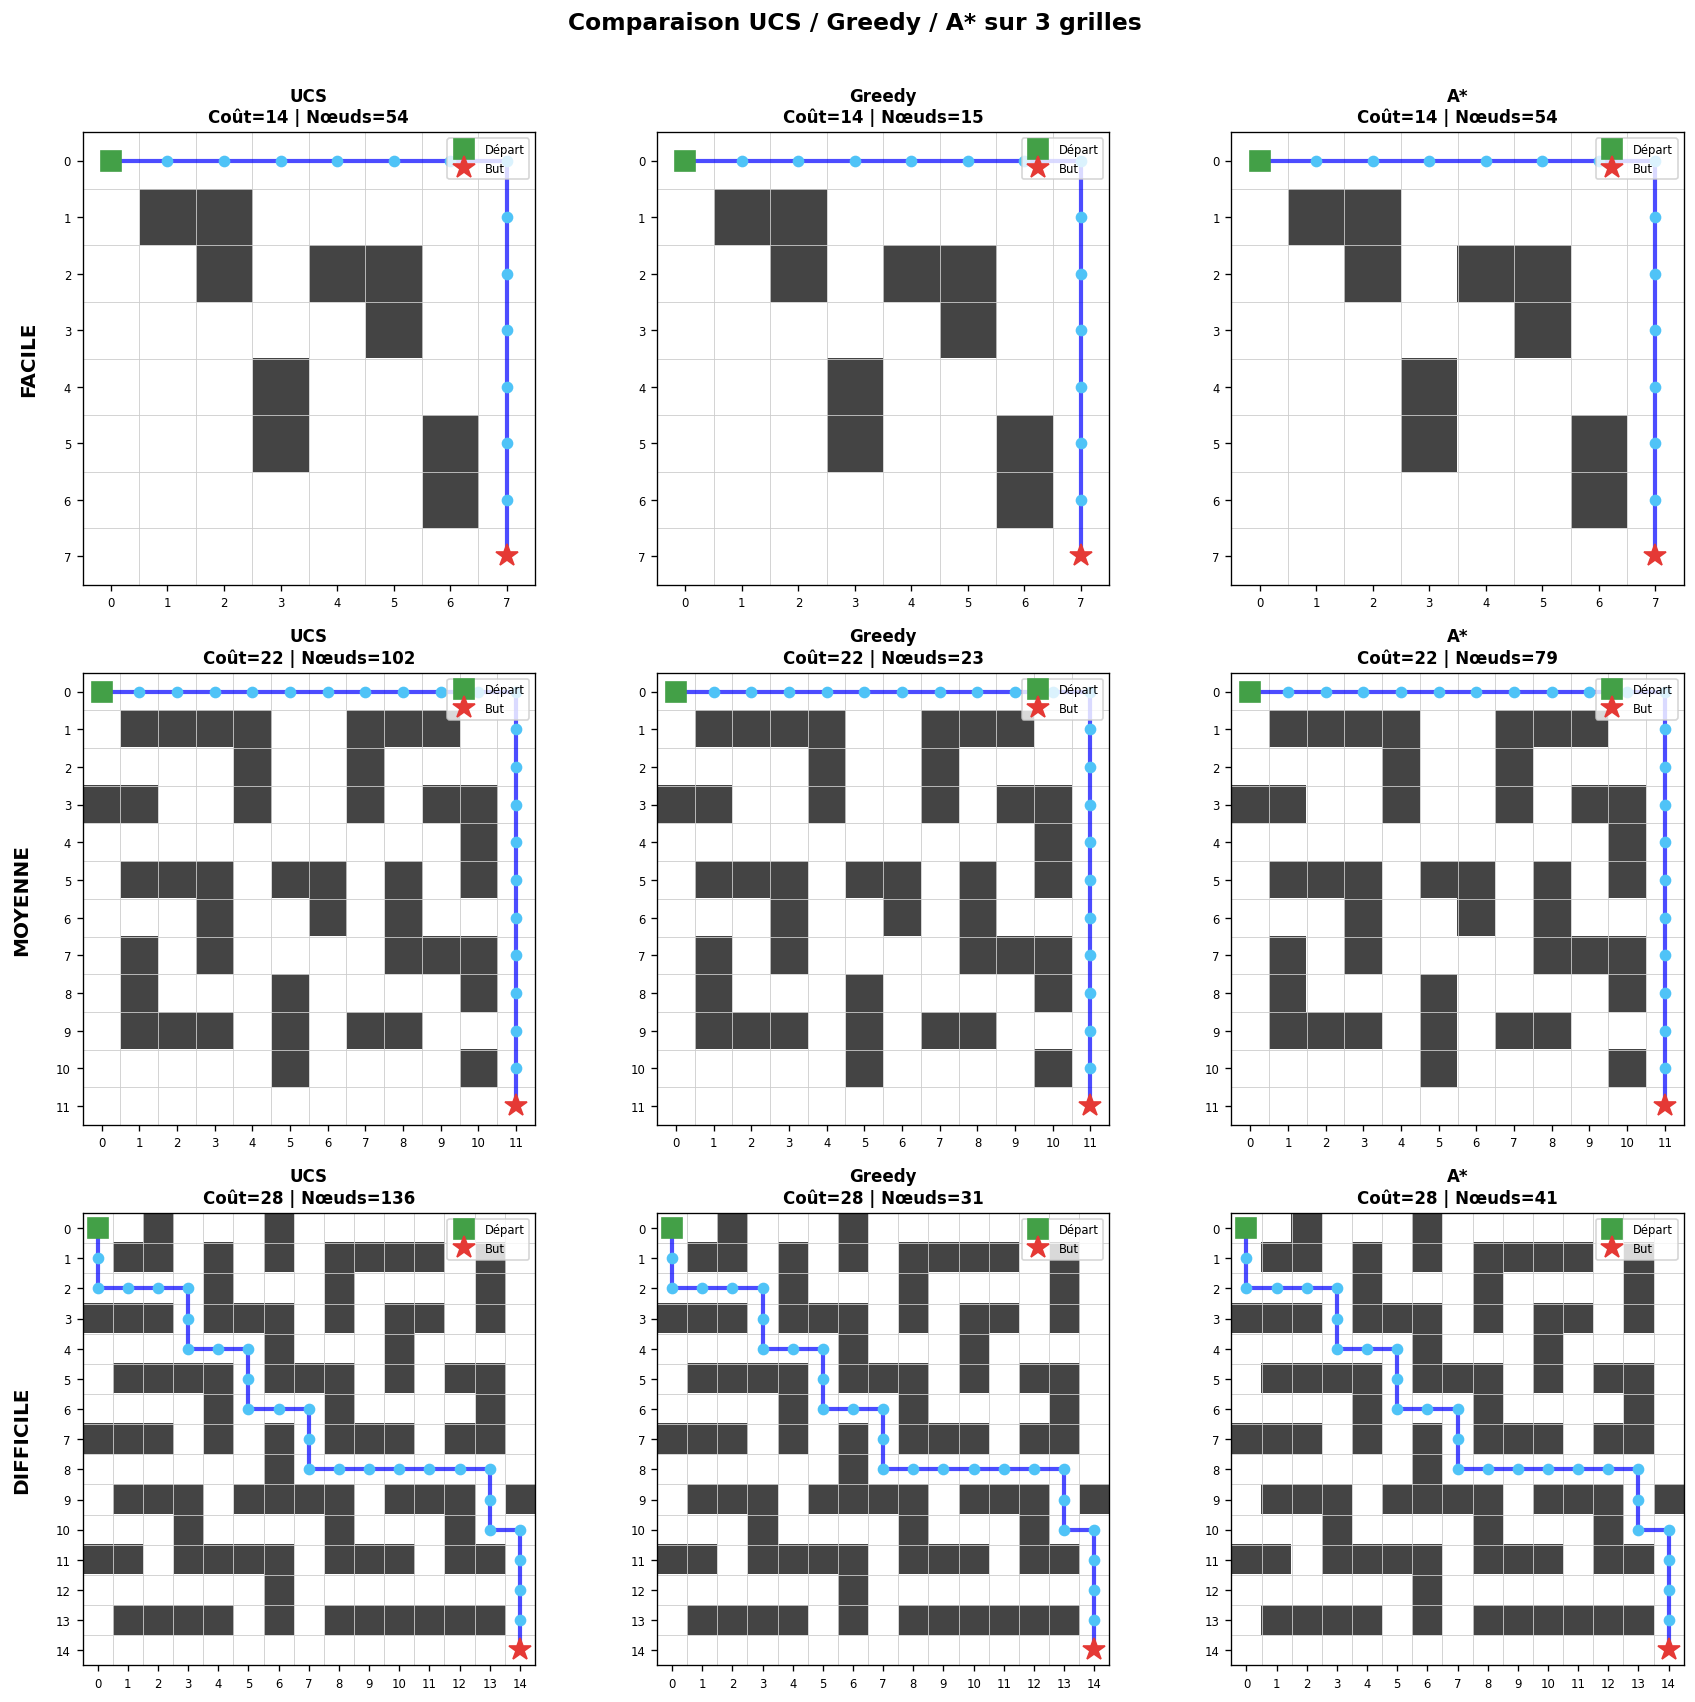

In [2]:
from experiments import experiment_E1
results_E1 = experiment_E1()
display(Image(filename='figures/E1_noeuds_barres.png'))
display(Image(filename='figures/E1_comparaison_algos.png'))

## E2 — Impact de ε sur le plan A*
ε varie de 0.0 à 0.3 sur la grille moyenne.                  
Calcul matriciel vs Monte-Carlo (3000 trajectoires).



EXPÉRIENCE E2 : Impact de ε sur la robustesse Markov
  Chemin A* : longueur=23, coût=22.0

       ε   P(GOAL) MC    P(GOAL) Matrice    Temps moyen    P(FAIL)
  ------ ------------ ------------------ -------------- ----------
     0.0       1.0000             1.0000          22.00     0.0000
     0.1       0.6353             0.6470          24.04     0.3647
     0.2       0.3963             0.3844          26.48     0.6037
     0.3       0.2027             0.2039          29.67     0.7973

  Figures sauvegardées!


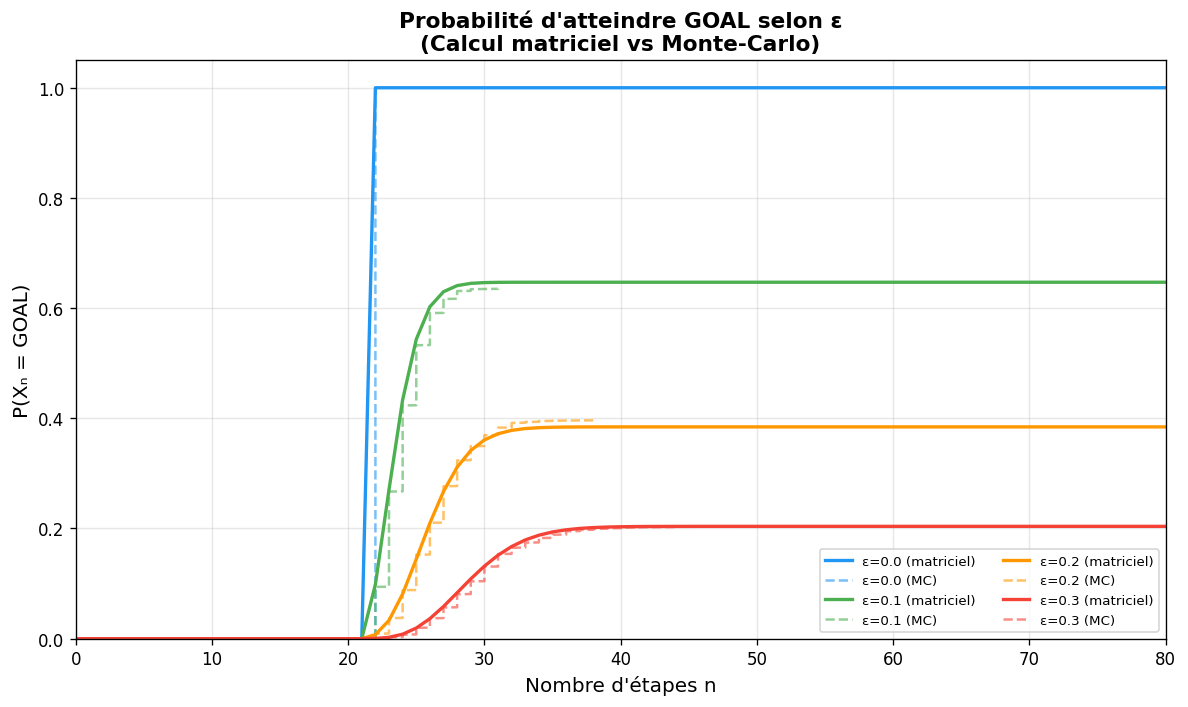

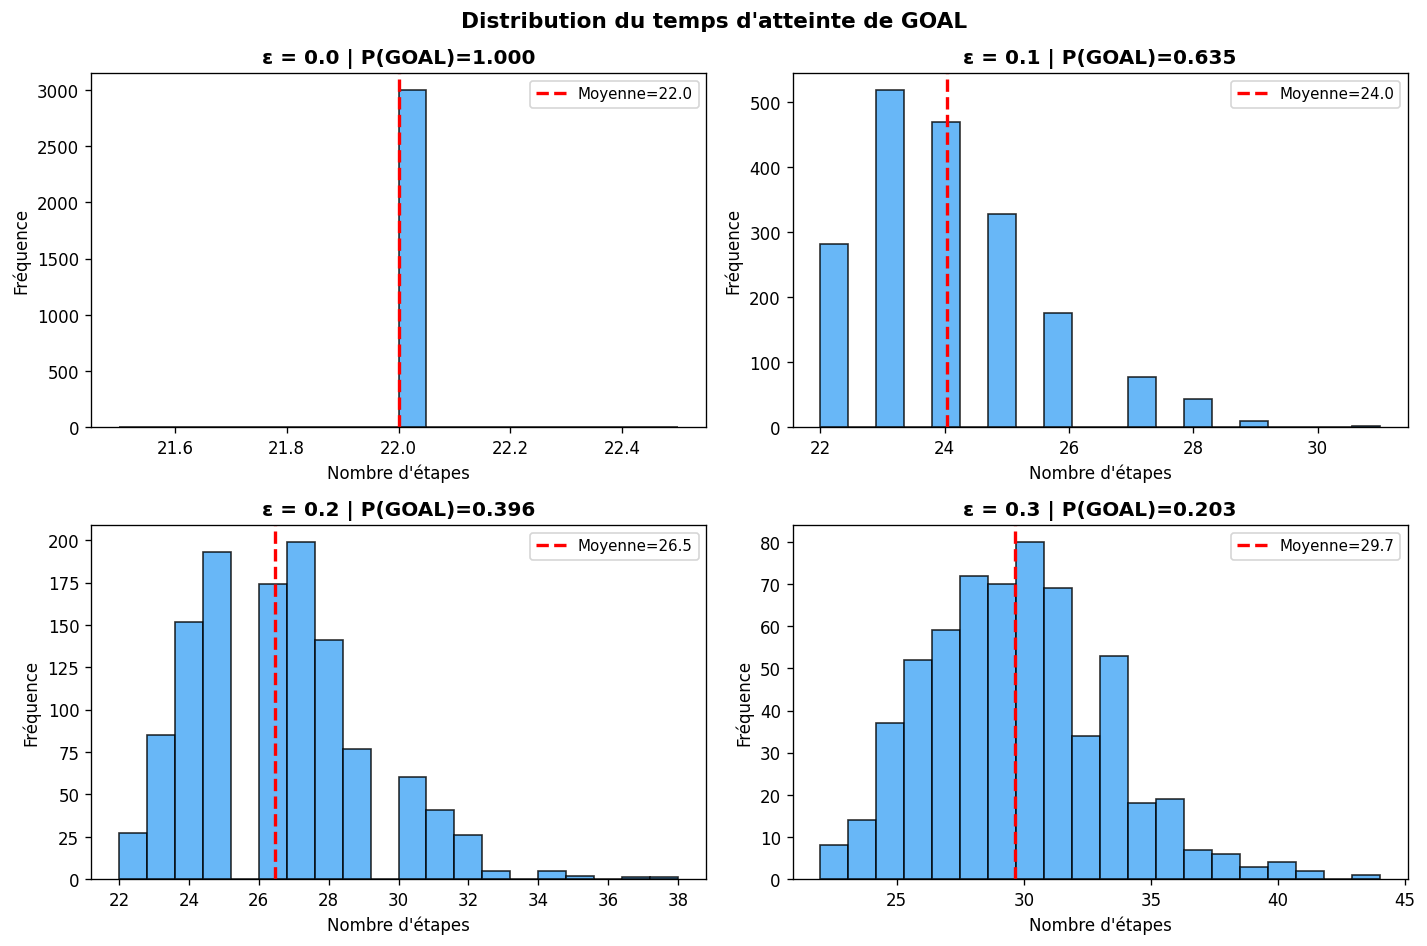

In [3]:
from experiments import experiment_E2
results_E2 = experiment_E2()
display(Image(filename='figures/E2_epsilon_impact.png'))
display(Image(filename='figures/E2_distribution_temps.png'))

## E3 — Heuristiques admissibles
Comparaison h=0, Manhattan et Euclidienne.  
Vérification de l'admissibilité, cohérence et dominance.


EXPÉRIENCE E3 : Comparaison heuristiques admissibles

  Grille FACILE:
  Heuristique                Coût    Nœuds   Admissible
  ---------------------- -------- -------- ------------
  A* h=0 (UCS)               14.0       54          Oui
  A* h=Manhattan             14.0       54          Oui
  A* h=Euclidienne           14.0       54          Oui

  Grille MOYENNE:
  Heuristique                Coût    Nœuds   Admissible
  ---------------------- -------- -------- ------------
  A* h=0 (UCS)               22.0      102          Oui
  A* h=Manhattan             22.0       79          Oui
  A* h=Euclidienne           22.0       84          Oui

  Grille DIFFICILE:
  Heuristique                Coût    Nœuds   Admissible
  ---------------------- -------- -------- ------------
  A* h=0 (UCS)               28.0      136          Oui
  A* h=Manhattan             28.0       41          Oui
  A* h=Euclidienne           28.0       65          Oui

  Figure sauvegardée!


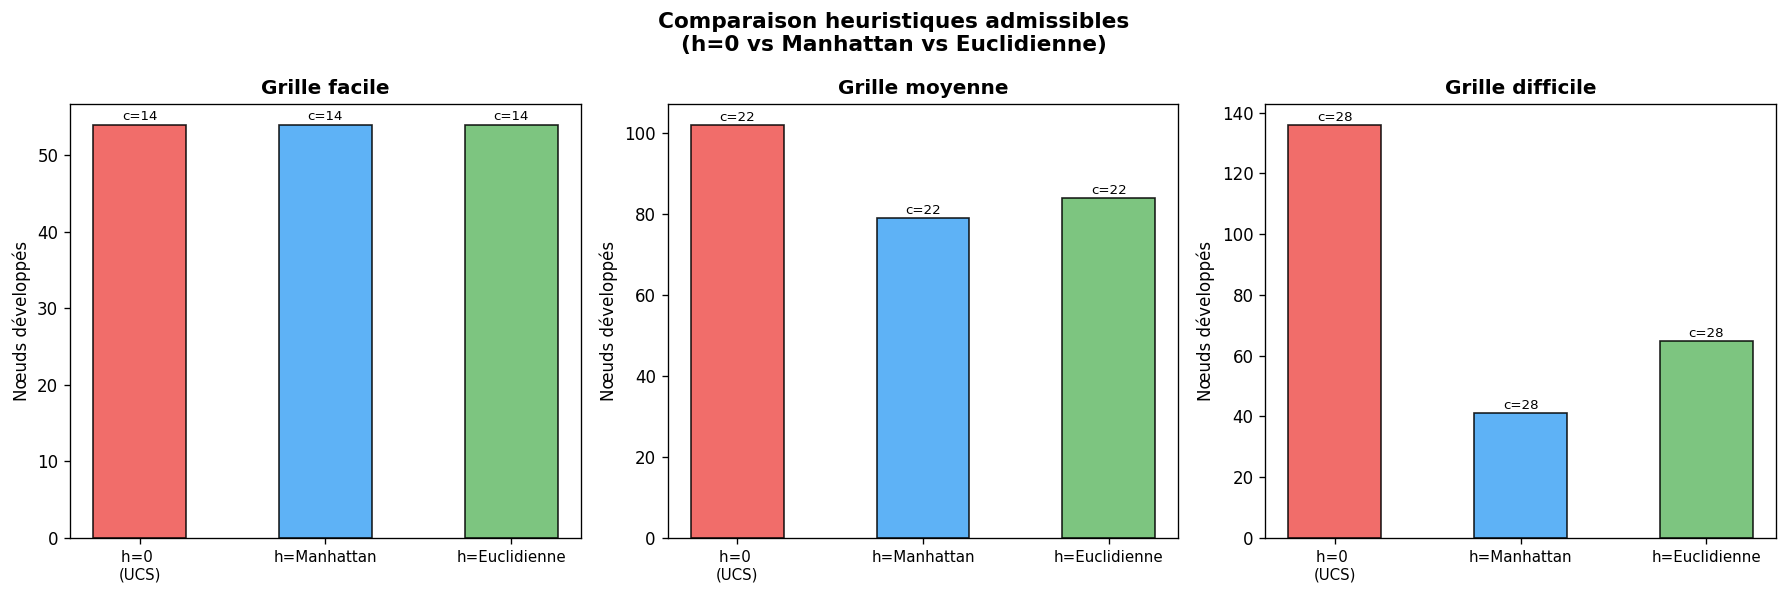

In [4]:
from experiments import experiment_E3
results_E3 = experiment_E3()
display(Image(filename='figures/E3_heuristiques.png'))

## E4 — Weighted A*
Poids w de 1.0 à 5.0 sur la grille difficile.              
Étude du compromis nœuds développés / optimalité du coût.


EXPÉRIENCE E4 (Option) : Weighted A* — vitesse vs optimalité

  Coût optimal (A*, w=1): 28.0

     Poids w     Coût    Ratio    Nœuds    Temps(ms)
  ---------- -------- -------- -------- ------------
         1.0     28.0    1.000       41        0.944
         1.5     28.0    1.000       31        1.011
         2.0     28.0    1.000       31        0.687
         3.0     28.0    1.000       31        0.500
         5.0     28.0    1.000       31        0.321

  Figure sauvegardée!


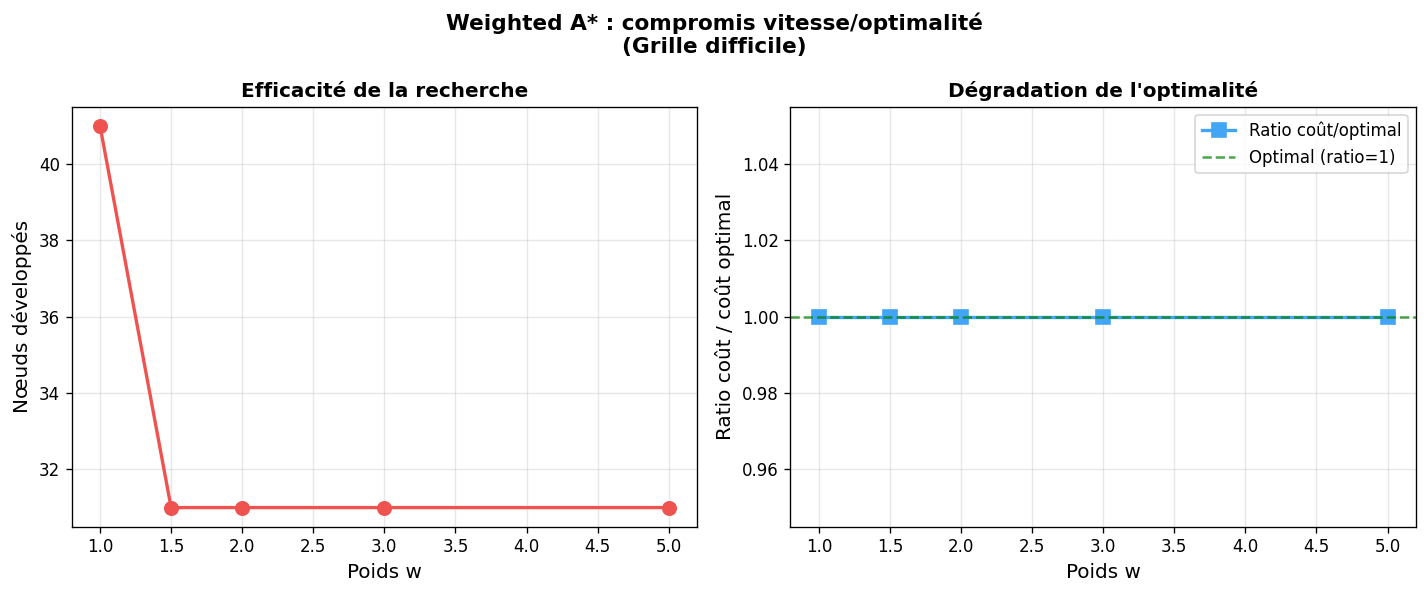

In [5]:
from experiments import experiment_E4
results_E4 = experiment_E4()
display(Image(filename='figures/E4_weighted_astar.png'))

## E5 — Analyse Markov complète
Grille facile, ε=0.15. Graphe de transitions, classes, absorption et validation MC vs matriciel.


EXPÉRIENCE E5 : Analyse Markov — Classes, Absorption, Validation

  Grille facile | ε=0.15 | |états|=16
  Matrice P stochastique: True

  Classes de communication (15 classes):
    Classe 1: Transitoire | États: ['(0,0)']
    Classe 2: Transitoire | États: ['(0,1)']
    Classe 3: Transitoire | États: ['(0,2)']
    Classe 4: Transitoire | États: ['(0,3)']
    Classe 5: Transitoire | États: ['(0,4)']
    Classe 6: Transitoire | États: ['(0,5)']
    Classe 7: Transitoire | États: ['(0,6)', '(0,7)']
    Classe 8: Transitoire | États: ['(1,7)']
    Classe 9: Transitoire | États: ['(2,7)']
    Classe 10: Transitoire | États: ['(3,7)']
    Classe 11: Transitoire | États: ['(4,7)']
    Classe 12: Transitoire | États: ['(5,7)']
    Classe 13: Transitoire | États: ['(6,7)']
    Classe 14: Récurrent (persistant) | États: ['(7,7)']
    Classe 15: Récurrent (persistant) | États: ['FAIL']

  Absorption (états transitoires: 14):
  Temps moyen avant absorption (depuis départ): 11.17 étapes
  P(GOAL d

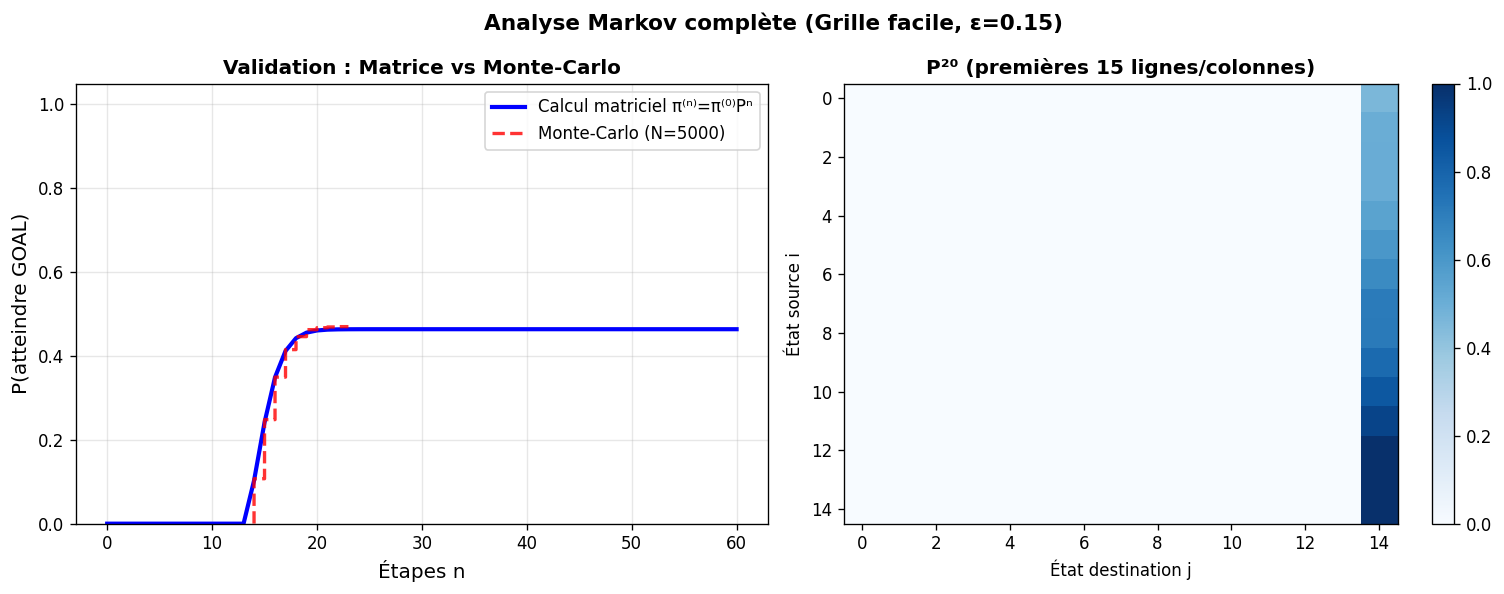

In [6]:
from experiments import experiment_E5
results_E5 = experiment_E5()
display(Image(filename='figures/E5_markov_analyse.png'))